Install & Import Libraries

In [1]:
import torch
torch.cuda.empty_cache()

In [ ]:
!nvidia-smi

Tue Mar 31 20:29:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader, random_split

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import precision_score, recall_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Hyperparameters

In [3]:
BATCH_SIZE = 128
EPOCHS = 100
LEARNING_RATE = 0.01
TRAIN_SIZE = 45000
VAL_SIZE = 5000

Dataset Loading & Preprocessing

In [4]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset_full = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_test
)

100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s]


Normalization

In [5]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    ),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    ),
])

Train/Validation Split

In [6]:
train_dataset, val_dataset = random_split(
    train_dataset_full,
    [TRAIN_SIZE, VAL_SIZE]
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 45000
Validation: 5000
Test: 10000


Load DenseNet-121 Model

In [7]:
model = models.densenet121(weights=None)

model.features.conv0 = nn.Conv2d(
    3, 64, kernel_size=3, stride=1, padding=1, bias=False
)

model.features.pool0 = nn.Identity()

model.classifier = nn.Linear(
    model.classifier.in_features, 10
)

# Modify classifier for CIFAR-10
num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, 10)

model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total Trainable Parameters:", total_params)

Total Trainable Parameters: 6956426


Loss, Optimizer (SGD)

In [8]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4
)

In [9]:
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[100, 150],
    gamma=0.1
)

In [10]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
transforms.RandomErasing(p=0.5)

RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3), value=0, inplace=False)

Training + Validation Loop

In [11]:

train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_acc = 0

for epoch in range(EPOCHS):

    # ---- Training ----
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100 * correct / total
    train_losses.append(train_loss/len(train_loader))
    train_accs.append(train_acc)

    # ---- Validation ----
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc = 100 * correct / total
    val_losses.append(val_loss/len(val_loader))
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_acc:.2f}")
    print(f"Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_acc:.2f}")

    torch.save({
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_accs': train_accs,
    'val_accs': val_accs
}, 'checkpoint.pth')

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_densenet121.pth")



Epoch 1/100
Train Loss: 1.7526 | Train Acc: 42.92
Val Loss: 1.9185 | Val Acc: 38.36
Epoch 2/100
Train Loss: 1.3544 | Train Acc: 61.57
Val Loss: 1.4995 | Val Acc: 55.44
Epoch 3/100
Train Loss: 1.1927 | Train Acc: 69.29
Val Loss: 1.3109 | Val Acc: 64.34
Epoch 4/100
Train Loss: 1.0558 | Train Acc: 75.62
Val Loss: 1.3111 | Val Acc: 63.66
Epoch 5/100
Train Loss: 0.9722 | Train Acc: 79.51
Val Loss: 1.0544 | Val Acc: 75.34
Epoch 6/100
Train Loss: 0.9252 | Train Acc: 81.69
Val Loss: 1.1513 | Val Acc: 71.70
Epoch 7/100
Train Loss: 0.8964 | Train Acc: 82.95
Val Loss: 1.0401 | Val Acc: 76.50
Epoch 8/100
Train Loss: 0.8728 | Train Acc: 83.81
Val Loss: 1.0257 | Val Acc: 77.10
Epoch 9/100
Train Loss: 0.8563 | Train Acc: 84.68
Val Loss: 0.9455 | Val Acc: 79.56
Epoch 10/100
Train Loss: 0.8443 | Train Acc: 85.16
Val Loss: 1.1251 | Val Acc: 74.32
Epoch 11/100
Train Loss: 0.8332 | Train Acc: 85.66
Val Loss: 0.9862 | Val Acc: 79.20
Epoch 12/100
Train Loss: 0.8265 | Train Acc: 85.98
Val Loss: 0.9865 | Val 

In [ ]:
checkpoint = torch.load('checkpoint.pth')

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

start_epoch = checkpoint['epoch'] + 1

train_losses = checkpoint['train_losses']
val_losses = checkpoint['val_losses']
train_accs = checkpoint['train_accs']
val_accs = checkpoint['val_accs']

Test Evaluation + Table + Plots

     Metric      Train  Validation       Test
0  Accuracy  89.673333   80.960000  86.400000
1      Loss   0.743505    0.945957   0.822982
Test Precision: 0.8687232666026586
Test Recall: 0.8640000000000001


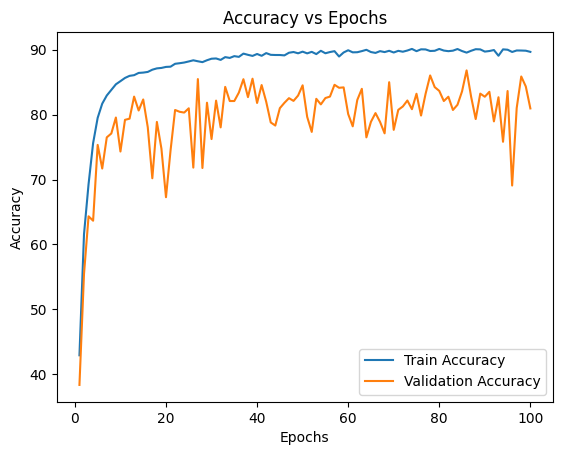

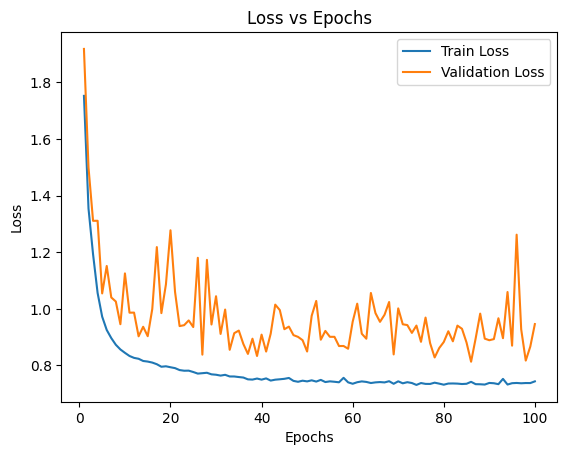

In [12]:
# Load best model
model.load_state_dict(torch.load("best_densenet121.pth"))
model.eval()

test_loss = 0
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100 * correct / total
test_loss = test_loss/len(test_loader)

precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')

# Final Table
results = pd.DataFrame({
    "Metric": ["Accuracy", "Loss"],
    "Train": [train_accs[-1], train_losses[-1]],
    "Validation": [val_accs[-1], val_losses[-1]],
    "Test": [test_acc, test_loss]
})

print(results)

print("Test Precision:", precision)
print("Test Recall:", recall)

# ---- Plot Curves ----
epochs = range(1, EPOCHS+1)

plt.figure()
plt.plot(epochs, train_accs, label="Train Accuracy")
plt.plot(epochs, val_accs, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy vs Epochs")
plt.show()

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss vs Epochs")
plt.show()